# Image processing

Figures shown in *Image processing* section in the work are from here.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import xarray

import datasets

## Non-climate image -- Urban100
Urban100 image -> conversion to 1 channel gray image

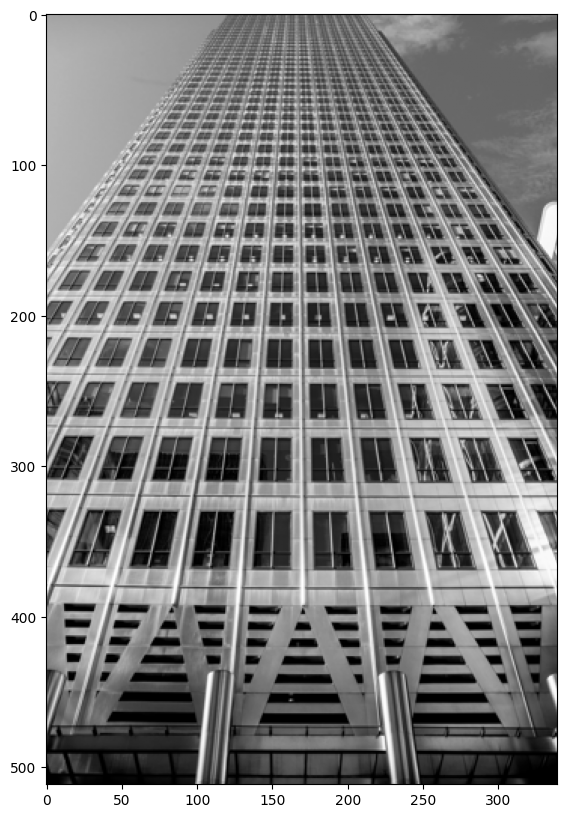

In [2]:
img = plt.imread('img_030.png')
img = np.dot(img[...,:3], [0.299, 0.587, 0.114])
img = torch.from_numpy(img).float()
plt.figure(figsize=(10, 10))
plt.imshow(img, cmap='gray')
plt.show()

Derivatives with respect to x and y using simple kernels

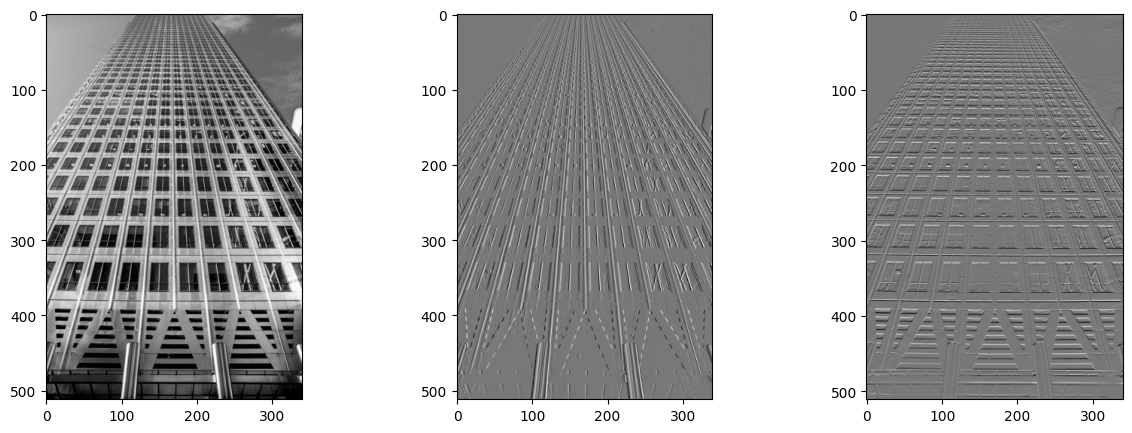

In [3]:
x_kernel = torch.tensor([1, -1], dtype=torch.float).reshape(1, 1, 1, -1)
y_kernel = torch.tensor([[1], [-1]], dtype=torch.float).reshape(1, 1, -1, 1)
dx = torch.conv2d(img.unsqueeze(0), weight=x_kernel)
dy = torch.conv2d(img.unsqueeze(0), weight=y_kernel)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(img, cmap='gray')
axs[1].imshow(dx.squeeze(), cmap='gray')
axs[2].imshow(dy.squeeze(), cmap='gray')
plt.show()

And the simple gradient magnitude.

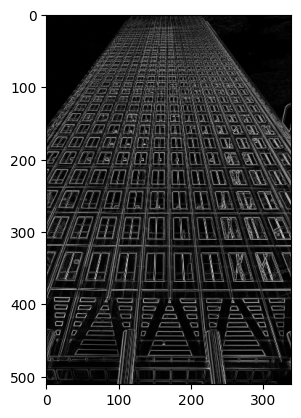

In [4]:
plt.imshow((dx[0, :-1,:].pow(2) + dy[0, :, :-1].pow(2)).sqrt().squeeze(), cmap='gray')

Derivatives with respect to x and y using the Sobel kernels

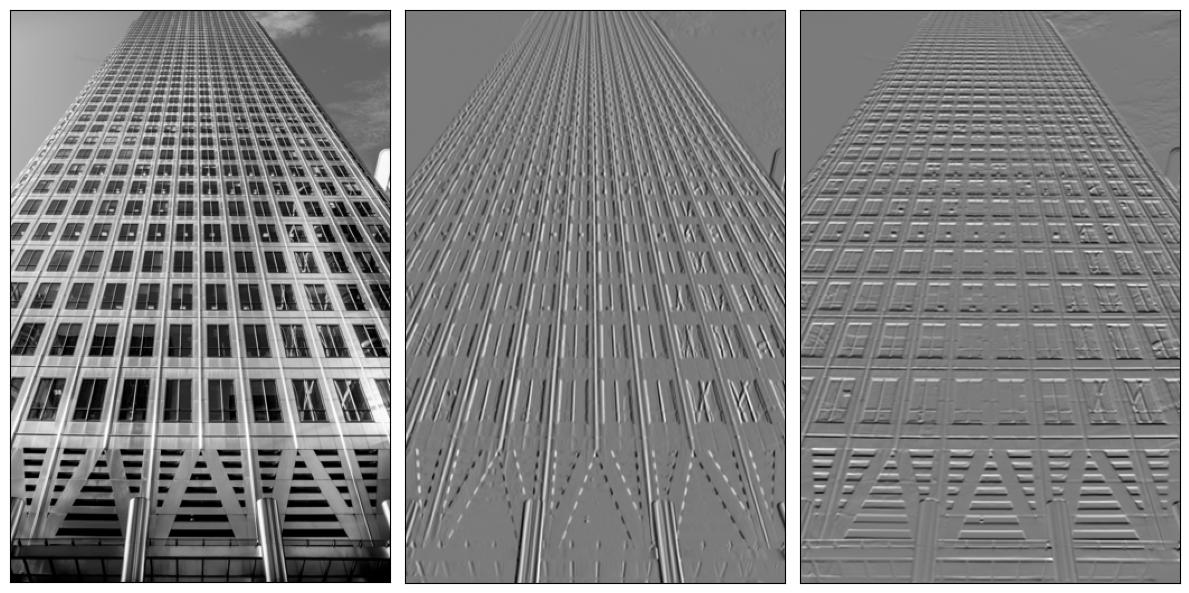

In [15]:
x_kernel = torch.tensor([[1, 0, -1], [2, 0, -2], [1, 0, -1]], dtype=torch.float).reshape(1, 1, 3, 3)
y_kernel = torch.tensor([[1, 2, 1], [0, 0, 0], [-1, -2, -1]], dtype=torch.float).reshape(1, 1, 3, 3)
dx = torch.conv2d(img.unsqueeze(0), weight=x_kernel)
dy = torch.conv2d(img.unsqueeze(0), weight=y_kernel)

fig, axs = plt.subplots(1, 3, figsize=(12, 9), rasterized= True)

axs[0].imshow(img, cmap='gray')
axs[0].xaxis.set_visible(False)
axs[0].yaxis.set_visible(False)

vmin = min(dx.min(), dy.min())
vmax = max(dx.max(), dy.max())

axs[1].imshow(dx.squeeze(), cmap='gray', vmin=vmin, vmax=vmax)
axs[1].xaxis.set_visible(False)
axs[1].yaxis.set_visible(False)

axs[2].imshow(dy.squeeze(), cmap='gray', vmin=vmin, vmax=vmax)
axs[2].xaxis.set_visible(False)
axs[2].yaxis.set_visible(False)

fig.tight_layout()

plt.show()

fig.savefig('images/derivatives.pdf', bbox_inches='tight', dpi = 300)

And the gradient magnitude

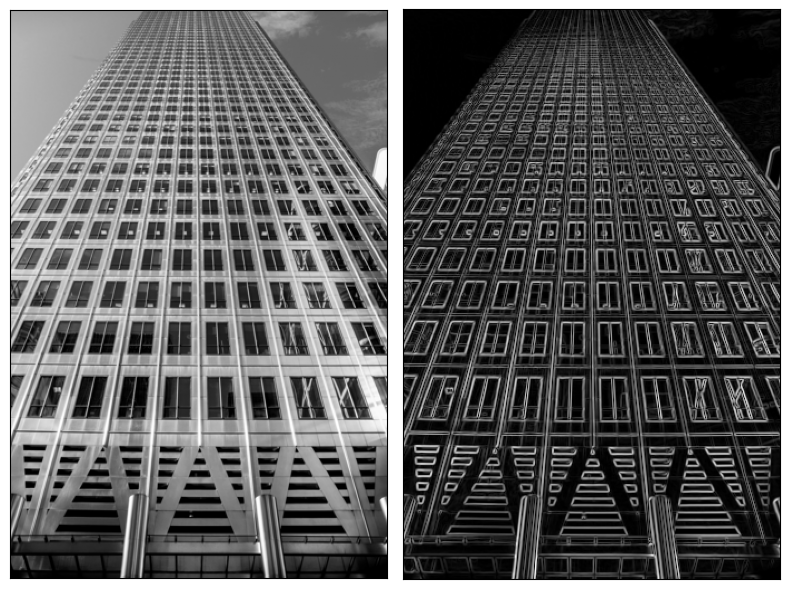

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(8, 9))

axs[0].imshow(img, cmap='gray')
axs[0].xaxis.set_visible(False)
axs[0].yaxis.set_visible(False)

axs[1].imshow((dx.pow(2) + dy.pow(2)).sqrt().squeeze(), cmap='gray', rasterized=True)
axs[1].xaxis.set_visible(False)
axs[1].yaxis.set_visible(False)

fig.tight_layout()
plt.show()

fig.savefig('images/gradient_magnitude.pdf', bbox_inches='tight', dpi = 300)

## Climate image -- ReKIS

torch.Size([1, 1, 25, 25]) torch.Size([1, 1, 400, 400])


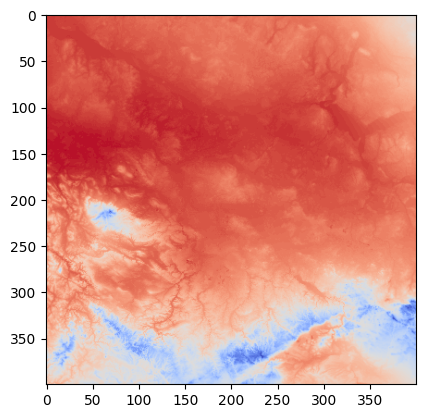

In [7]:
PATH = '/home/tomas/ctu/current/rci_data/climate/ReKIS/KlimRefDS_v3.1_1961-2023/Raster/Tag/GK4/TM'

Y = xarray.open_mfdataset(PATH + "/*.nc", decode_coords="all")
Y = Y['TM']
dataset = datasets.ReKIS(Y.sel(time='2000-02-01'), 16)

X, Y = dataset.X.reshape((1, 1, 25, 25)), dataset.Y.reshape((1, 1, 400, 400))
print(X.shape, Y.shape)

plt.imshow(Y.squeeze(), cmap='coolwarm')
plt.show()

Sobel kernels

In [8]:
x_kernel = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32)
x_kernel = torch.reshape(x_kernel, (1, 1, 3, 3))
y_kernel = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=torch.float32)
y_kernel = torch.reshape(y_kernel, (1, 1, 3, 3))

LR derivatives

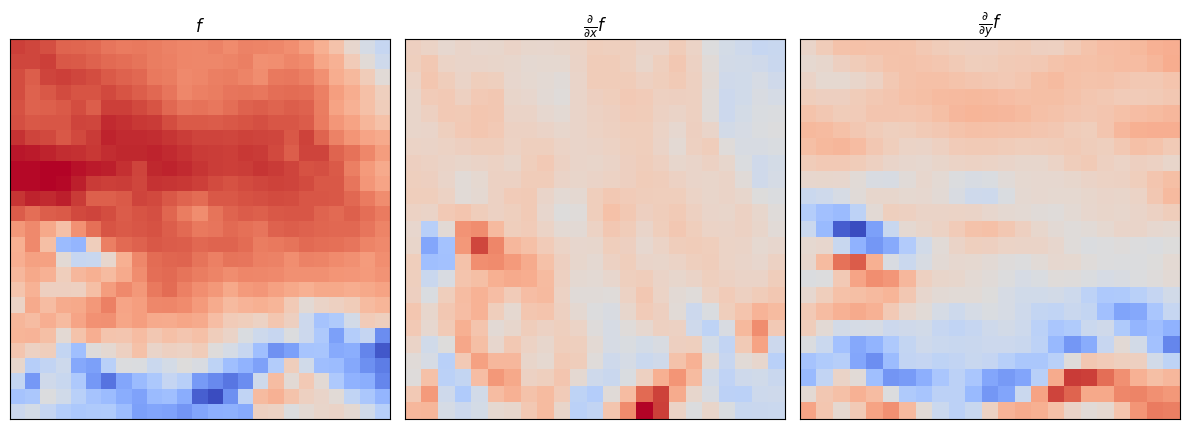

In [9]:
dx = torch.conv2d(X, weight=x_kernel)
dy = torch.conv2d(X, weight=y_kernel)

fig, axs = plt.subplots(1, 3, figsize=(12, 9), rasterized= True)

axs[0].imshow(X.squeeze(), cmap='coolwarm')
axs[0].set_title(r'$f$')
axs[0].xaxis.set_visible(False)
axs[0].yaxis.set_visible(False)

vmin = min(dx.min(), dy.min())
vmax = max(dx.max(), dy.max())

axs[1].imshow(dx.squeeze(), cmap='coolwarm', vmin=vmin, vmax=vmax)
axs[1].set_title(r'$\frac{\partial}{\partial x}f$')
axs[1].xaxis.set_visible(False)
axs[1].yaxis.set_visible(False)

axs[2].imshow(dy.squeeze(), cmap='coolwarm', vmin=vmin, vmax=vmax)
axs[2].set_title(r'$\frac{\partial}{\partial y}f$')
axs[2].xaxis.set_visible(False)
axs[2].yaxis.set_visible(False)

fig.tight_layout()

plt.show()

LR gradient magnitude

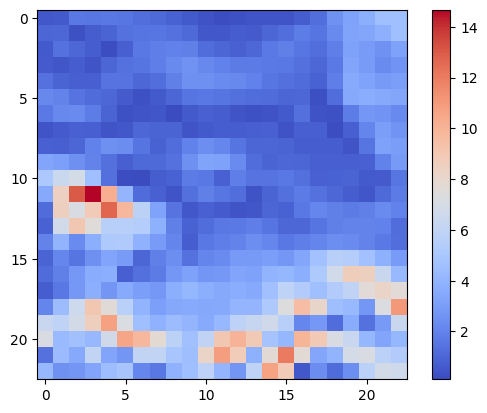

In [10]:
plt.imshow((dx.pow(2) + dy.pow(2)).sqrt().squeeze(), cmap='coolwarm')
plt.colorbar()
plt.show()

LR gradient

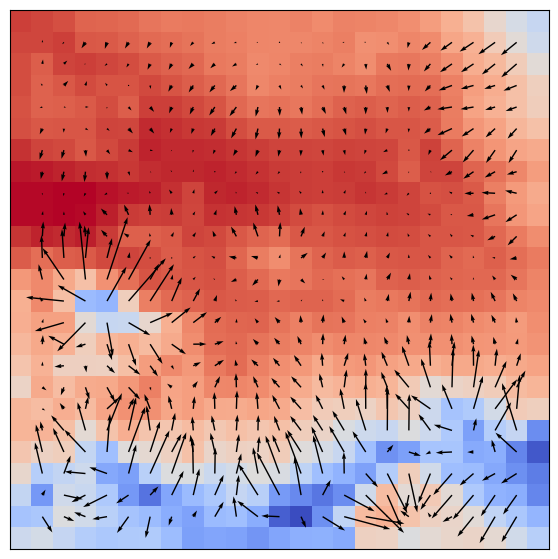

In [11]:
y,x= np.mgrid[1:24, 1:24]

fig, ax = plt.subplots(1, 1, figsize=(7, 7), rasterized= True)

ax.imshow(X.squeeze(), cmap='coolwarm')
ax.quiver(x, y, dx.squeeze().numpy(), -dy.squeeze().numpy())
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)

plt.show()
fig.savefig('images/climate_gradient.pdf', bbox_inches='tight', dpi = 300)

The mean dilated derivatives are the same as LR derivatives!

In [12]:
dilated_x = torch.conv2d(input=Y, weight=x_kernel, dilation=(16, 16))
dilated_x = torch.nn.functional.avg_pool2d(dilated_x, kernel_size=16, stride=16)

dilated_y = torch.conv2d(input=Y, weight=y_kernel, dilation=(16, 16))
dilated_y = torch.nn.functional.avg_pool2d(dilated_y, kernel_size=16, stride=16)

(dilated_x - dx).abs().mean(), (dilated_y - dy).abs().mean()

(tensor(8.0650e-07), tensor(1.3220e-06))